# 06 — Bin calibration on known fog density

Severity bin boundaries are derived here, from the only data where fog density is
known: Foggy Cityscapes renders each clear Cityscapes scene at three physical fog
densities (β = 0.005, 0.01, 0.02). The severity distributions of the four known
conditions are inspected visually first; boundaries are then placed where adjacent
distributions cross (the severity value at which a scene is equally likely to belong
to either neighbouring density), minimising misassignment between known levels.
Direction anchor: a dark-channel fog-density index matches labelled Cityscapes fog
levels at ~0.98 accuracy (Guo, Wang & Li, 2022).

In [1]:
# Setup and inventory: list only CAMERA images (excluding gtFine annotation
# rasters), parse the fog density (beta) from filenames, count images per
# condition, and show one scene at all four known fog levels.
import os
import re
import glob
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')

RAW_ROOT = "/content/drive/MyDrive/adaptive_perception_data/raw"
CLEAR_DIR = os.path.join(RAW_ROOT, "cityscapes")
FOGGY_DIR = os.path.join(RAW_ROOT, "foggy_cityscapes")
OUTPUT_ROOT = "/content/drive/MyDrive/perception-difficulty-dve/results"
TABLES_DIR = os.path.join(OUTPUT_ROOT, "tables")
FIGURES_DIR = os.path.join(OUTPUT_ROOT, "figures")

# Fog density beta -> plain meaning (visibility ~ 3 / beta; Sakaridis et al. 2018).
BETA_MEANING = {
    0.005: "light fog, ~600 m visibility",
    0.01: "moderate fog, ~300 m visibility",
    0.02: "heavy fog, ~150 m visibility",
}


Mounted at /content/drive


In [3]:
# --- Step 1: list camera images only -----------------------------------------
# Cityscapes camera frames end in _leftImg8bit.png; the accompanying gtFine
# rasters (_gtFine_color / _labelIds / _instanceIds) are label images, not photos.
clear_paths = sorted(glob.glob(
    os.path.join(CLEAR_DIR, "**", "*_leftImg8bit.png"), recursive=True))
foggy_paths = sorted(glob.glob(
    os.path.join(FOGGY_DIR, "**", "*_leftImg8bit_foggy_beta_*.png"), recursive=True))
print(f"cityscapes camera images:       {len(clear_paths)}")
print(f"foggy_cityscapes camera images: {len(foggy_paths)}")


cityscapes camera images:       5000
foggy_cityscapes camera images: 15000


In [4]:
# --- Step 2: parse beta and split from each path ------------------------------
def parse_beta(path):
    match = re.search(r"beta_([0-9]+\.[0-9]+)", os.path.basename(path))
    return float(match.group(1)) if match else None

def parse_split(path):
    for split_name in ("train", "val", "test"):
        if f"{os.sep}{split_name}{os.sep}" in path:
            return split_name
    return "unknown"

foggy_info = pd.DataFrame({
    "path": foggy_paths,
    "beta": [parse_beta(p) for p in foggy_paths],
    "split": [parse_split(p) for p in foggy_paths],
})
clear_info = pd.DataFrame({
    "path": clear_paths,
    "split": [parse_split(p) for p in clear_paths],
})

print("\nfoggy images per split and beta:")
print(foggy_info.groupby(["split", "beta"]).size().to_string())
print("\nclear images per split:")
print(clear_info.groupby("split").size().to_string())




foggy images per split and beta:
split  beta 
test   0.005    1525
       0.010    1525
       0.020    1525
train  0.005    2975
       0.010    2975
       0.020    2975
val    0.005     500
       0.010     500
       0.020     500

clear images per split:
split
test     1525
train    2975
val       500



val scenes with clear + 3 fog levels: 500
Saved: /content/drive/MyDrive/perception-difficulty-dve/results/figures/fig_16_known_fog_levels_cityscapes.jpg


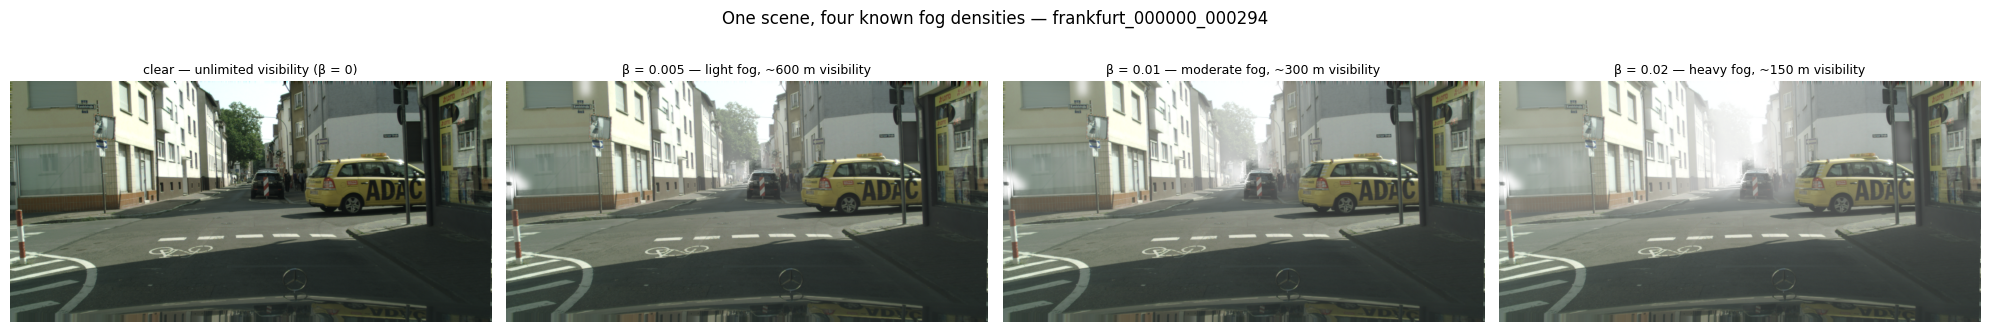

In [5]:
# --- Step 3: one scene at all four known fog levels ---------------------------
def scene_id(path):
    return os.path.basename(path).split("_leftImg8bit")[0]

foggy_info["scene"] = foggy_info["path"].map(scene_id)
clear_info["scene"] = clear_info["path"].map(scene_id)

val_scenes = set(clear_info[clear_info["split"] == "val"]["scene"])
val_foggy = foggy_info[foggy_info["split"] == "val"]
complete = [s for s in sorted(val_scenes) if (val_foggy["scene"] == s).sum() >= 3]
print(f"\nval scenes with clear + 3 fog levels: {len(complete)}")

example = complete[0]
panels = [("clear — unlimited visibility (β = 0)",
           clear_info[(clear_info["scene"] == example) & (clear_info["split"] == "val")]["path"].iloc[0])]
for beta in sorted(val_foggy["beta"].dropna().unique()):
    row = val_foggy[(val_foggy["scene"] == example) & (val_foggy["beta"] == beta)]
    panels.append((f"β = {beta} — {BETA_MEANING[beta]}", row["path"].iloc[0]))

fig, axes = plt.subplots(1, len(panels), figsize=(5 * len(panels), 3.2))
for ax, (title, path) in zip(axes, panels):
    ax.imshow(cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB))
    ax.set_title(title, fontsize=9)
    ax.axis("off")
fig.suptitle(f"One scene, four known fog densities — {example}", fontsize=12, y=1.05)
plt.tight_layout()

figure_path = os.path.join(FIGURES_DIR, "fig_16_known_fog_levels_cityscapes.jpg")
plt.savefig(figure_path, dpi=100, format="jpg", bbox_inches="tight")
print("Saved:", figure_path)
plt.show()

In [6]:
# Build the calibration worklist: every val scene at its four known fog levels.
CONDITION_NAME = {0.0: "clear", 0.005: "light", 0.01: "moderate", 0.02: "heavy"}

clear_val = clear_info[clear_info["split"] == "val"].copy()
clear_val["beta"] = 0.0
foggy_val = foggy_info[foggy_info["split"] == "val"].copy()

worklist = pd.concat([clear_val[["path", "scene", "beta"]],
                      foggy_val[["path", "scene", "beta"]]], ignore_index=True)
worklist["condition"] = worklist["beta"].map(CONDITION_NAME)

print(worklist.groupby("condition").size().to_string())
print(f"\ntotal images to score: {len(worklist)}")

condition
clear       500
heavy       500
light       500
moderate    500

total images to score: 2000


In [7]:
# Copy the 2,000 worklist images to local disk. Skips files already copied.
import shutil

LOCAL_CAL_DIR = "/content/data/cityscapes_val"
os.makedirs(LOCAL_CAL_DIR, exist_ok=True)

copied, skipped = 0, 0
for count, path in enumerate(worklist["path"], start=1):
    destination = os.path.join(LOCAL_CAL_DIR, os.path.basename(path))
    if os.path.exists(destination):
        skipped += 1
    else:
        shutil.copy(path, destination)
        copied += 1
    if count % 500 == 0:
        print(f"  {count} / {len(worklist)}")

worklist["local_path"] = worklist["path"].map(
    lambda p: os.path.join(LOCAL_CAL_DIR, os.path.basename(p)))
print(f"copied {copied}, already present {skipped}")

  500 / 2000
  1000 / 2000
  1500 / 2000
  2000 / 2000
copied 2000, already present 0


In [8]:
# Import the severity estimator from the repo; verify before any computation.
import sys, importlib

REPO_ROOT = "/content/perception-difficulty-dve"
REPO_URL = "https://github.com/aaaraafaat/perception-difficulty-dve.git"
if not os.path.isdir(REPO_ROOT):
    os.system(f"git clone {REPO_URL} {REPO_ROOT}")
os.system(f"cd {REPO_ROOT} && git pull")
if REPO_ROOT not in sys.path:
    sys.path.append(REPO_ROOT)

import src.features as feat
importlib.reload(feat)

required = ["airlight_estimate", "transmission_map", "dcp_severity_score"]
missing = [name for name in required if not hasattr(feat, name)]
if missing:
    raise ImportError(f"features.py missing {missing} — push from Cursor, rerun.")
print("Severity estimator loaded:", ", ".join(required))

Severity estimator loaded: airlight_estimate, transmission_map, dcp_severity_score


In [9]:
# Score severity for the 2,000 calibration images (clear + three known fog
# densities). Resumes from the saved CSV: already-scored files are skipped,
# and progress is saved to Drive every 250 images.
import cv2

calibration_path = os.path.join(TABLES_DIR, "severity_calibration_cityscapes.csv")

if os.path.exists(calibration_path):
    scored = pd.read_csv(calibration_path)
else:
    scored = pd.DataFrame(columns=["filename", "scene", "condition", "beta", "severity"])
already_done = set(scored["filename"])
print(f"already scored: {len(already_done)} of {len(worklist)}")

records = scored.to_dict("records")
for _, row in worklist.iterrows():
    name = os.path.basename(row["path"])
    if name in already_done:
        continue
    image_bgr = cv2.imread(row["local_path"])
    if image_bgr is None:
        continue
    records.append({
        "filename": name,
        "scene": row["scene"],
        "condition": row["condition"],
        "beta": row["beta"],
        "severity": feat.dcp_severity_score(image_bgr),
    })
    if len(records) % 250 == 0:
        pd.DataFrame(records).to_csv(calibration_path, index=False)
        print(f"  saved {len(records)} / {len(worklist)}")

calibration = pd.DataFrame(records)
calibration.to_csv(calibration_path, index=False)
print(f"Saved {len(calibration)} rows to {calibration_path}")

print("\nSeverity by known condition:")
print(calibration.groupby("condition")["severity"].describe().round(3).to_string())

already scored: 2000 of 2000
Saved 2000 rows to /content/drive/MyDrive/perception-difficulty-dve/results/tables/severity_calibration_cityscapes.csv

Severity by known condition:
           count   mean    std    min    25%    50%    75%    max
condition                                                        
clear      500.0  0.216  0.043  0.108  0.190  0.216  0.238  0.433
heavy      500.0  0.481  0.053  0.332  0.447  0.482  0.516  0.677
light      500.0  0.315  0.051  0.190  0.279  0.313  0.348  0.589
moderate   500.0  0.383  0.053  0.249  0.347  0.381  0.418  0.629


Saved: /content/drive/MyDrive/perception-difficulty-dve/results/figures/fig_17_severity_by_known_density.jpg


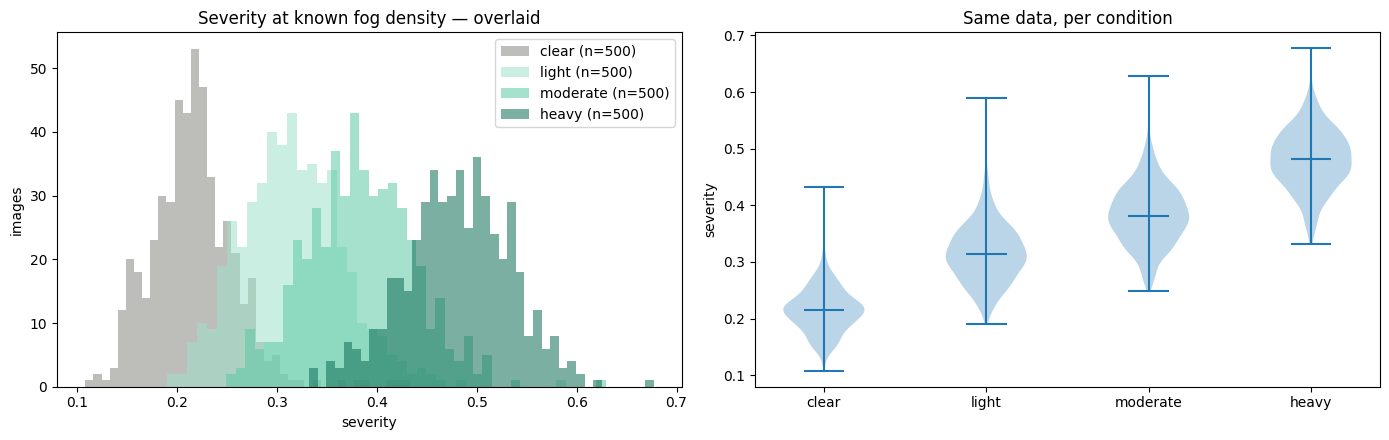

           count   mean  median    std
condition                             
clear        500  0.216   0.216  0.043
light        500  0.315   0.313  0.051
moderate     500  0.383   0.381  0.053
heavy        500  0.481   0.482  0.053


In [10]:
# The four severity distributions under KNOWN fog density. The instrument is fit
# for binning only if the known conditions separate and order correctly:
# clear < light (~600 m) < moderate (~300 m) < heavy (~150 m).
calibration = pd.read_csv(calibration_path)
order = ["clear", "light", "moderate", "heavy"]
colors = {"clear": "#888780", "light": "#9FE1CB", "moderate": "#5DCAA5", "heavy": "#0F6E56"}

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for condition in order:
    values = calibration.loc[calibration["condition"] == condition, "severity"]
    axes[0].hist(values, bins=40, alpha=0.55, color=colors[condition],
                 label=f"{condition} (n={len(values)})")
axes[0].set_xlabel("severity"); axes[0].set_ylabel("images"); axes[0].legend()
axes[0].set_title("Severity at known fog density — overlaid")

data = [calibration.loc[calibration["condition"] == c, "severity"] for c in order]
axes[1].violinplot(data, showmedians=True)
axes[1].set_xticks(range(1, 5)); axes[1].set_xticklabels(order)
axes[1].set_ylabel("severity"); axes[1].set_title("Same data, per condition")
plt.tight_layout()

figure_path = os.path.join(FIGURES_DIR, "fig_17_severity_by_known_density.jpg")
plt.savefig(figure_path, dpi=110, format="jpg", bbox_inches="tight")
print("Saved:", figure_path)
plt.show()

print(calibration.groupby("condition")["severity"]
      .agg(["count", "mean", "median", "std"]).round(3).loc[order].to_string())

In [11]:
# Derive bin boundaries: for each adjacent pair of known conditions, the
# boundary is the severity value where the two distributions cross (equal
# density), estimated by KDE between the two means.
import numpy as np
from scipy.stats import gaussian_kde

pairs = [("clear", "light"), ("light", "moderate"), ("moderate", "heavy")]
boundaries = []
for lower, upper in pairs:
    values_lower = calibration.loc[calibration["condition"] == lower, "severity"].values
    values_upper = calibration.loc[calibration["condition"] == upper, "severity"].values
    kde_lower, kde_upper = gaussian_kde(values_lower), gaussian_kde(values_upper)
    grid = np.linspace(values_lower.mean(), values_upper.mean(), 2000)
    difference = kde_lower(grid) - kde_upper(grid)
    sign_changes = np.where(np.diff(np.sign(difference)) != 0)[0]
    crossing = float(grid[sign_changes[0]]) if len(sign_changes) else float(grid.mean())
    boundaries.append({"between": f"{lower}/{upper}", "boundary": round(crossing, 3)})
    print(f"{lower:>8} / {upper:<8} boundary = {crossing:.3f}")

boundaries_table = pd.DataFrame(boundaries)
boundaries_path = os.path.join(TABLES_DIR, "severity_bin_boundaries.csv")
boundaries_table.to_csv(boundaries_path, index=False)
print("Saved:", boundaries_path)

   clear / light    boundary = 0.260
   light / moderate boundary = 0.350
moderate / heavy    boundary = 0.434
Saved: /content/drive/MyDrive/perception-difficulty-dve/results/tables/severity_bin_boundaries.csv


Saved: /content/drive/MyDrive/perception-difficulty-dve/results/figures/fig_18_bin_boundaries_cityscapes.jpg


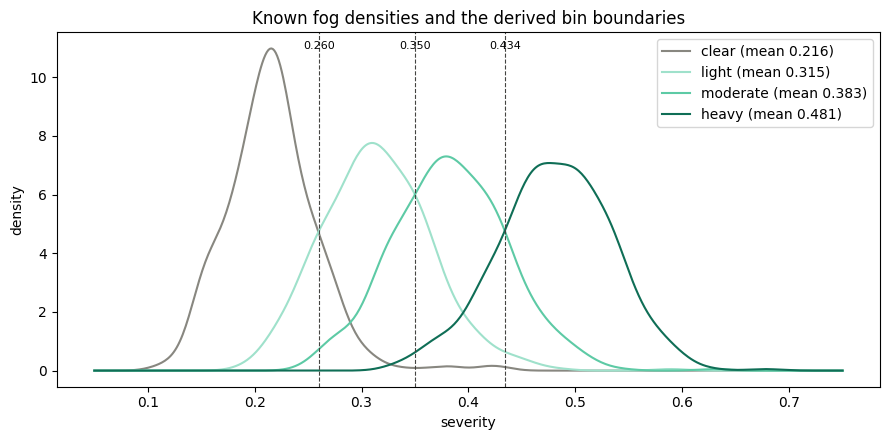

assigned   clear  light  moderate  heavy
condition                               
clear        438     56         6      0
light         76    304       110     10
moderate       2    131       287     80
heavy          0      4        87    409

agreement with known condition: 71.9%


In [12]:
# Visual: the four KDE curves with the derived boundaries. Test: assign every
# image by the boundaries and cross-tabulate against its KNOWN condition.
cuts = boundaries_table["boundary"].tolist()

fig, ax = plt.subplots(figsize=(9, 4.5))
grid = np.linspace(0.05, 0.75, 500)
for condition in order:
    values = calibration.loc[calibration["condition"] == condition, "severity"].values
    ax.plot(grid, gaussian_kde(values)(grid), color=colors[condition],
            label=f"{condition} (mean {values.mean():.3f})")
for cut in cuts:
    ax.axvline(cut, color="#444441", linewidth=0.8, linestyle="--")
    ax.text(cut, ax.get_ylim()[1] * 0.95, f"{cut:.3f}", ha="center", fontsize=8)
ax.set_xlabel("severity"); ax.set_ylabel("density"); ax.legend()
ax.set_title("Known fog densities and the derived bin boundaries")
plt.tight_layout()
figure_path = os.path.join(FIGURES_DIR, "fig_18_bin_boundaries_cityscapes.jpg")
plt.savefig(figure_path, dpi=110, format="jpg", bbox_inches="tight")
print("Saved:", figure_path)
plt.show()

bin_names = ["clear", "light", "moderate", "heavy"]
calibration["assigned"] = pd.cut(calibration["severity"],
                                 bins=[-np.inf] + cuts + [np.inf], labels=bin_names)
confusion = pd.crosstab(calibration["condition"], calibration["assigned"]).loc[order, bin_names]
accuracy = np.diag(confusion.values).sum() / confusion.values.sum()
print(confusion.to_string())
print(f"\nagreement with known condition: {accuracy:.1%}")

In [ ]:
# Effect sizes for the separation shown in fig_17: Cohen's d between adjacent
# known conditions, and overall monotonicity as Spearman rho between the known
# density (beta) and severity. d > 0.8 is conventionally large (Cohen, 1988).
from scipy.stats import spearmanr

def cohens_d(sample_a, sample_b):
    """Standardized mean difference between two samples (pooled SD)."""
    pooled_sd = np.sqrt(
        ((len(sample_a) - 1) * sample_a.std(ddof=1) ** 2 +
         (len(sample_b) - 1) * sample_b.std(ddof=1) ** 2) /
        (len(sample_a) + len(sample_b) - 2))
    return (sample_b.mean() - sample_a.mean()) / pooled_sd

adjacent = [("clear", "light"), ("light", "moderate"), ("moderate", "heavy")]
for lower, upper in adjacent:
    a = calibration.loc[calibration["condition"] == lower, "severity"]
    b = calibration.loc[calibration["condition"] == upper, "severity"]
    print(f"{lower:>8} -> {upper:<8}  Cohen's d = {cohens_d(a, b):.2f}")

rho, p_value = spearmanr(calibration["beta"], calibration["severity"])
print(f"\nSpearman rho (known beta vs severity) = {rho:.3f}   p = {p_value:.1e}   n = {len(calibration)}")

   clear -> light     Cohen's d = 2.09
   light -> moderate  Cohen's d = 1.30
moderate -> heavy     Cohen's d = 1.83

Spearman rho (known beta vs severity) = 0.893   p = 0.0e+00   n = 2000


## Closing — calibration result

The estimator was applied to 2,000 validation images of known fog density: the 500
Cityscapes val scenes, each clear and at three rendered densities (β = 0.005 / 0.01 /
0.02; visibility ≈ 3/β ≈ 600 / 300 / 150 m; Sakaridis, Dai & Van Gool, 2018).
Severity orders the four known conditions with no reversals — means 0.216 (clear),
0.315 (light), 0.383 (moderate), 0.481 (heavy) — and rises monotonically with true
density (Spearman ρ = 0.893, n = 2,000, p ≪ 0.001), consistent with the direction
validated for dark-channel density indices by Guo, Wang & Li (2022). Adjacent
conditions separate with large effect sizes (Cohen's d = 2.09 clear→light, 1.30
light→moderate, 1.83 moderate→heavy; Cohen, 1988). The weakest separation,
light→moderate, is also the physically subtlest distinction (600 m vs 300 m
visibility) — the effect-size pattern matches the optics.

Bin boundaries are placed at the crossing points of adjacent severity
distributions — the severity at which a scene is equally likely to belong to either
neighbouring density — giving 0.260 / 0.350 / 0.434. Assigning every calibration
image by these boundaries recovers its known condition in 71.9% of cases
(1,438 of 2,000, against a 25% chance level). The errors carry the structure the
distribution overlap predicts: 96% of misassignments (540 of 562) are one-bin slips
between neighbouring conditions, only 1.1% of images (22 of 2,000) land two or more
bins away, and the extreme confusions are empty in both directions (clear→heavy 0,
heavy→clear 0). The least-recovered condition is light (304 of 500), leaking into
both clear (76) and moderate (110) — again the pair with the smallest effect size.
The bins are therefore ordinal fog levels with an empirical, non-circular
calibration — not exact density measurements.

Outputs: severity_calibration_cityscapes.csv, severity_bin_boundaries.csv,
fig_16 (known levels), fig_17 (distributions), fig_18 (boundaries).
References: He, Sun & Tang (2009); Cohen (1988); Sakaridis, Dai & Van Gool (2018);
Guo, Wang & Li (2022).